In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os
from sumo_sim.file_path import FilePath as FP
from dataclasses import dataclass
from matplotlib.lines import Line2D

## Compute the average density across training seeds, test seeds, and all seeds

In [2]:
def average_density(*folders, output_file):
    # Load all CSV files from the given folders
    csv_files = sorted(
        f
        for folder in folders
        for f in Path("csv/"+folder).glob("*.csv")
    )

    # Read each CSV and use Timestep as the index
    dfs = [pd.read_csv(f).set_index("Timestep") for f in csv_files]

    print(f"Number of CSV files: {len(dfs)}")

    # Compute the element-wise average
    average = sum(dfs) / len(dfs)

    # Save the averaged data
    average.reset_index().to_csv("csv/"+output_file, index=False)

In [3]:
average_density("density_seed_train", output_file="density_train_seed.csv")
average_density("density_seed_test", output_file="density_test_seed.csv")
average_density("density_seed_train","density_seed_test", output_file="density_all_seed.csv")

Number of CSV files: 8
Number of CSV files: 50
Number of CSV files: 58


## Plot the Average Density Across Training Seeds, Test Seeds, and All Seeds

In [4]:
@dataclass(frozen=True)
class Tag:
    AVERAGE = "average"
    TRAIN = "individual_train"
    TEST = "individual_test"

def plot_average_density(density_file,tag):
    plt.figure(figsize=(6.4, 4.8))
    # print(plt.rcParams["figure.figsize"])

    os.makedirs(os.path.join(FP.sim_validator_pth,"fig"), exist_ok=True)
    if tag == Tag.AVERAGE:
        path = f"csv/density_{density_file}_seed.csv"
    else:
        raise ValueError(f"Invalid tag: {tag}")

    df = pd.read_csv(path)

    for col in df.columns[1:]:
        plt.scatter(df["Timestep"], df[col], s=20)
        plt.plot(df["Timestep"], df[col],marker="o",markersize=4, label=col, linewidth=1, alpha=0.6)

    plt.xlabel("Time-step")
    plt.ylabel("Density (pc/mi/ln)")

    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=len(df.columns) - 1,   # one row
        frameon=False
    )
    ax = plt.gca()
    ax.set_ylim(top=max(27.6, df[df.columns[1:]].max().max()))

    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    # ax.xaxis.set_minor_locator(MultipleLocator(10))
    # ax.yaxis.set_minor_locator(MultipleLocator(0.1))

    ax.minorticks_on()
    ax.grid(which="major", linewidth=0.9)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"fig/density_average_{density_file}_seed.pdf", dpi=300)

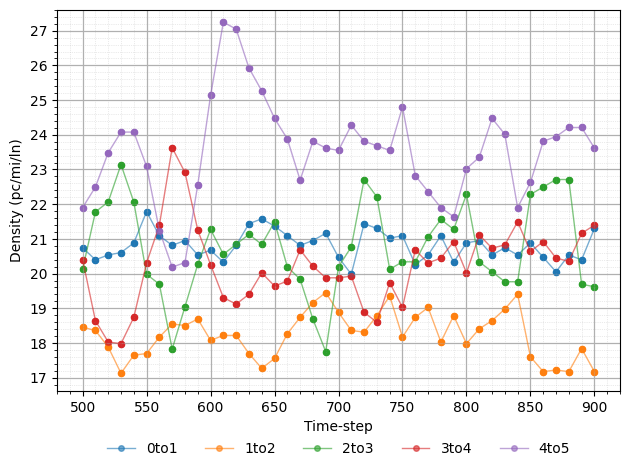

In [5]:
plot_average_density("train",tag=Tag.AVERAGE)

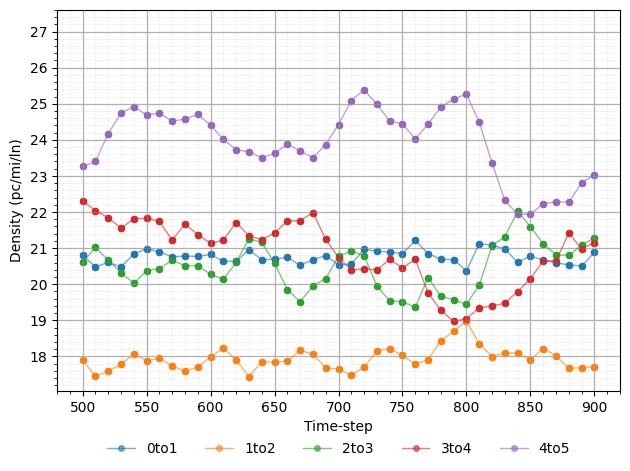

In [6]:
plot_average_density("test",tag=Tag.AVERAGE)

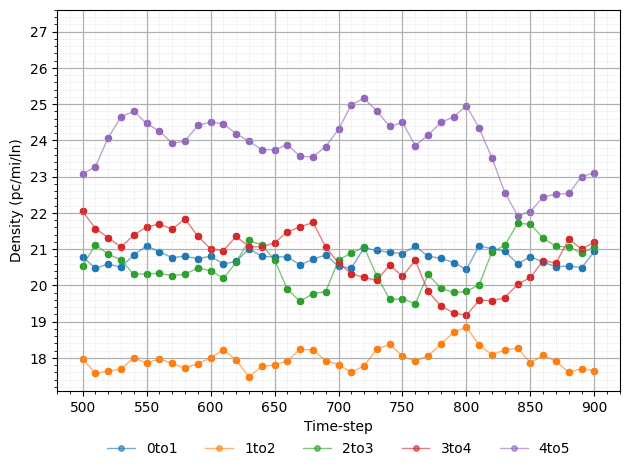

In [7]:
plot_average_density("all",tag=Tag.AVERAGE)

## Plot the Density of Individual Seeds

In [8]:
def plot_individual_density(seed,tag):
    plt.figure(figsize=(7, 6))
    # print(plt.rcParams["figure.figsize"])

    os.makedirs(os.path.join(FP.sim_validator_pth,"fig"), exist_ok=True)
    if tag == Tag.TRAIN:
        path = f"csv/density_seed_train/density_{seed}.csv"
    elif tag == Tag.TEST:
        path = f"csv/density_seed_test/density_{seed}.csv"
    else:
        raise ValueError(f"Invalid tag: {tag}")

    df = pd.read_csv(path)

    for col in df.columns[1:]:
        plt.scatter(df["Timestep"], df[col], s=20)
        plt.plot(df["Timestep"], df[col],marker="o",markersize=4, label=col, linewidth=1, alpha=0.6)

    plt.xlabel("Time-step")
    plt.ylabel("Density (pc/mi/ln)")

    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=len(df.columns) - 1,   # one row
        frameon=False
    )
    ax = plt.gca()
    ax.set_ylim(top=max(35, 1+df[df.columns[1:]].max().max()))

    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(2))

    # ax.xaxis.set_minor_locator(MultipleLocator(10))
    # ax.yaxis.set_minor_locator(MultipleLocator(0.1))

    ax.minorticks_on()
    ax.grid(which="major", linewidth=0.9)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"fig/density_{seed}.pdf", dpi=300)

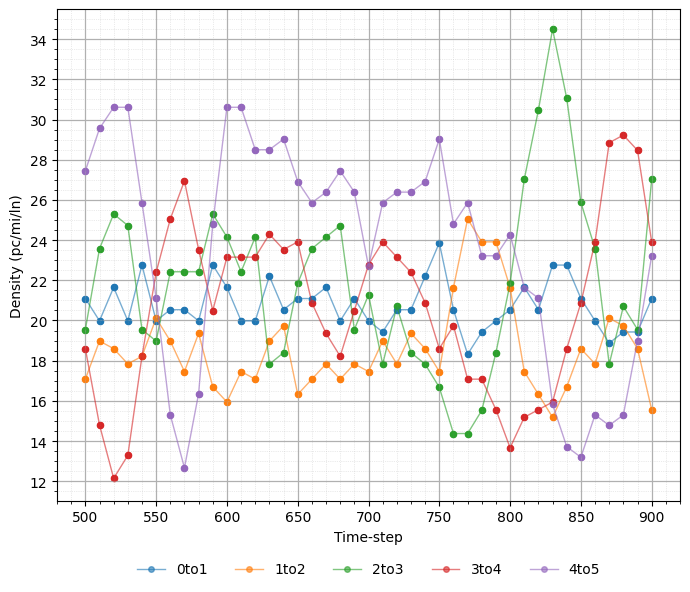

In [9]:
plot_individual_density(seed="23423",tag=Tag.TRAIN)

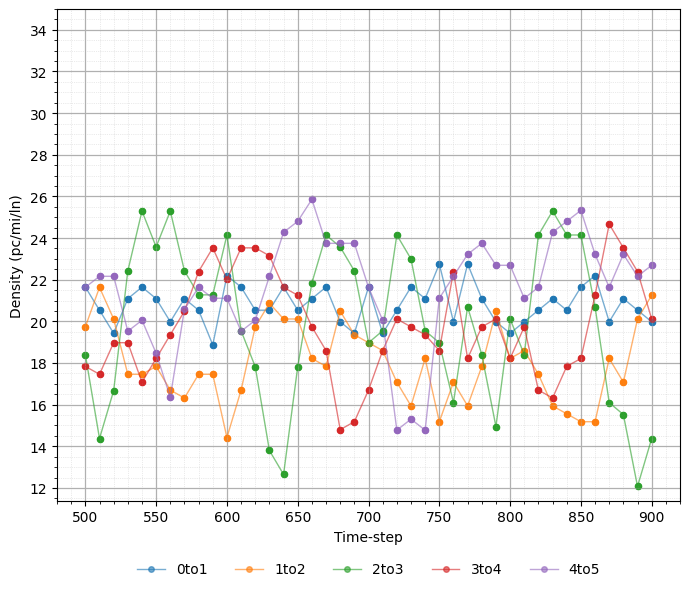

In [10]:
plot_individual_density(seed="123",tag=Tag.TRAIN)

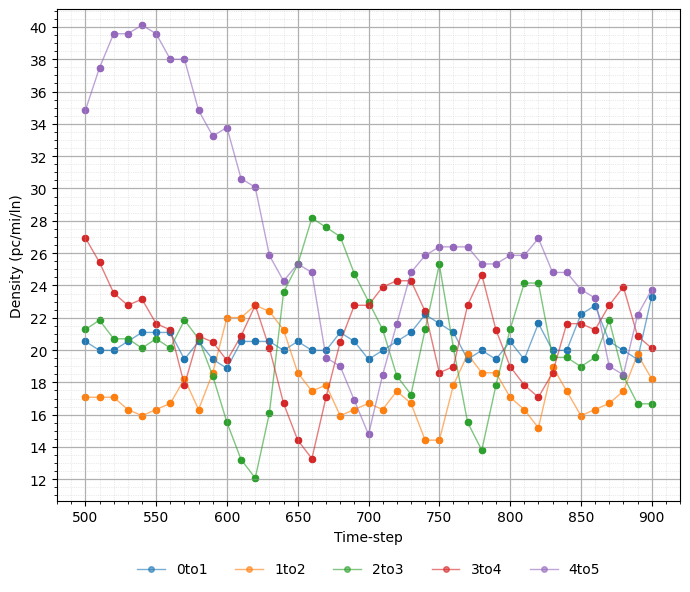

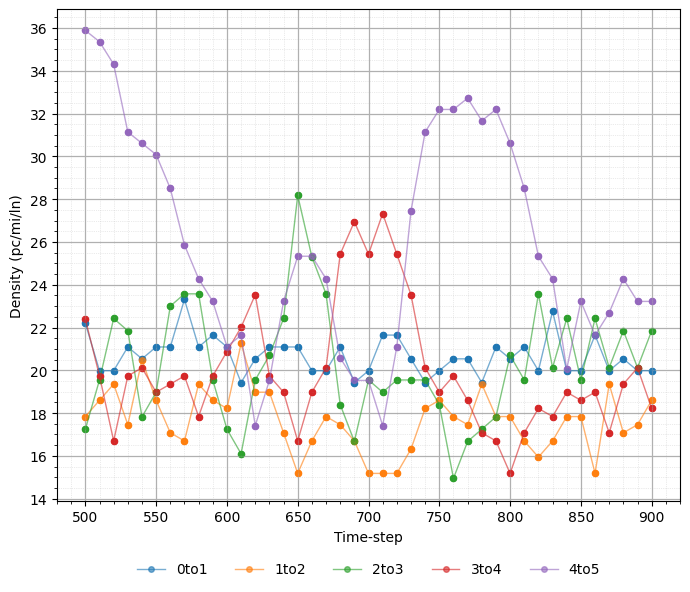

In [11]:
plot_individual_density("4572",tag=Tag.TEST)
plot_individual_density("29234",tag=Tag.TEST)

## plot all seed in one figure 

In [12]:
def plot_all_density(tag, subplots_dim, figsize):
    if tag== Tag.TEST:
        folder = Path("csv/density_seed_test")
    elif tag== Tag.TRAIN:
        folder = Path("csv/density_seed_train")
    else:
        raise ValueError(f"Invalid tag: {tag}")
    csv_files = sorted(folder.glob("*.csv"))

    fig, axes = plt.subplots(*subplots_dim, figsize=figsize, sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, csv_file in zip(axes, csv_files):
        df = pd.read_csv(csv_file)
        ax.set_ylim(top=max(40, df[df.columns[1:]].max().max()+5),bottom=5)

        for col in df.columns[1:]:
            ax.scatter(df["Timestep"], df[col], s=20)
            ax.plot(df["Timestep"], df[col],marker="o",markersize=4, label=col, linewidth=1, alpha=0.6)
        
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.1),
            ncol=len(df.columns) - 1,   # one row
            frameon=False
        )

        # Use the filename as the subplot title
        ax.set_title(csv_file.stem, fontsize=8)

        # Grid
        ax.xaxis.set_major_locator(MultipleLocator(50))
        ax.yaxis.set_major_locator(MultipleLocator(5))
        plt.grid(True)
        ax.minorticks_on()
        ax.grid(which="major", linewidth=0.9)
        ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)


    # Create a single legend for the whole figure
    # labels = df.columns[1:]

    # handles = [
    #     Line2D([], [], marker='o', linewidth=0.8, markersize=4, label=label)
    #     for label in labels
    # ]
    handles, labels = axes[0].get_legend_handles_labels()
    plt.legend(handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.09),
        ncol=len(labels),   # one row
        frameon=False
    )
    # Common labels
    fig.supxlabel("Time-step")
    fig.supylabel("Density (pc/mi/ln)")

    plt.tight_layout()
    
    if tag== Tag.TEST:
        plt.savefig(f"fig/density_individual_Test_seed.pdf", dpi=300)
    elif tag== Tag.TRAIN:
        plt.savefig(f"fig/density_individual_Train_seed.pdf", dpi=300)

    
    plt.show()

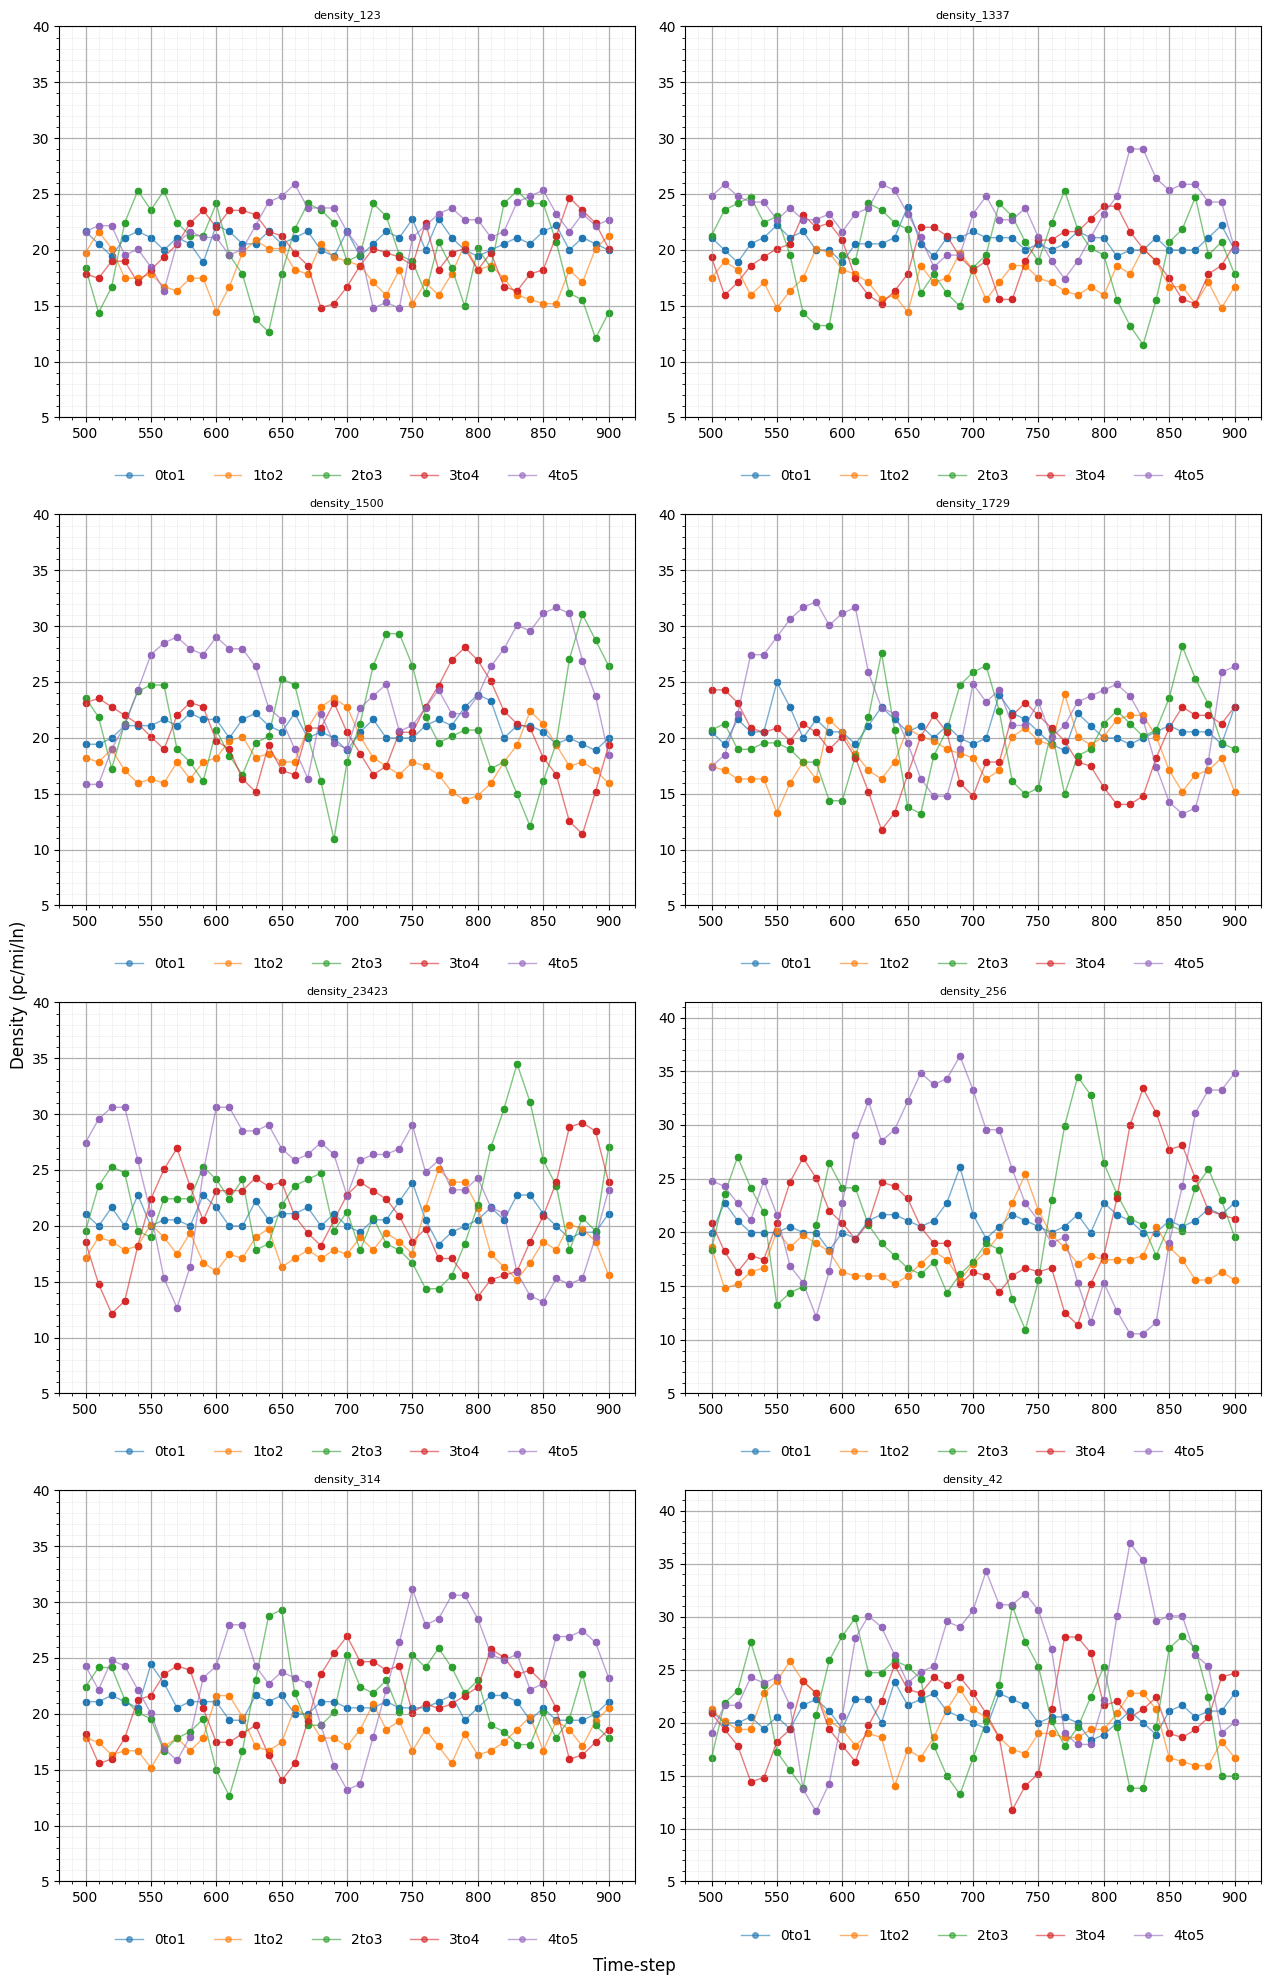

In [155]:
plot_all_density(tag=Tag.TRAIN, subplots_dim=(4,2), figsize=(13,20))

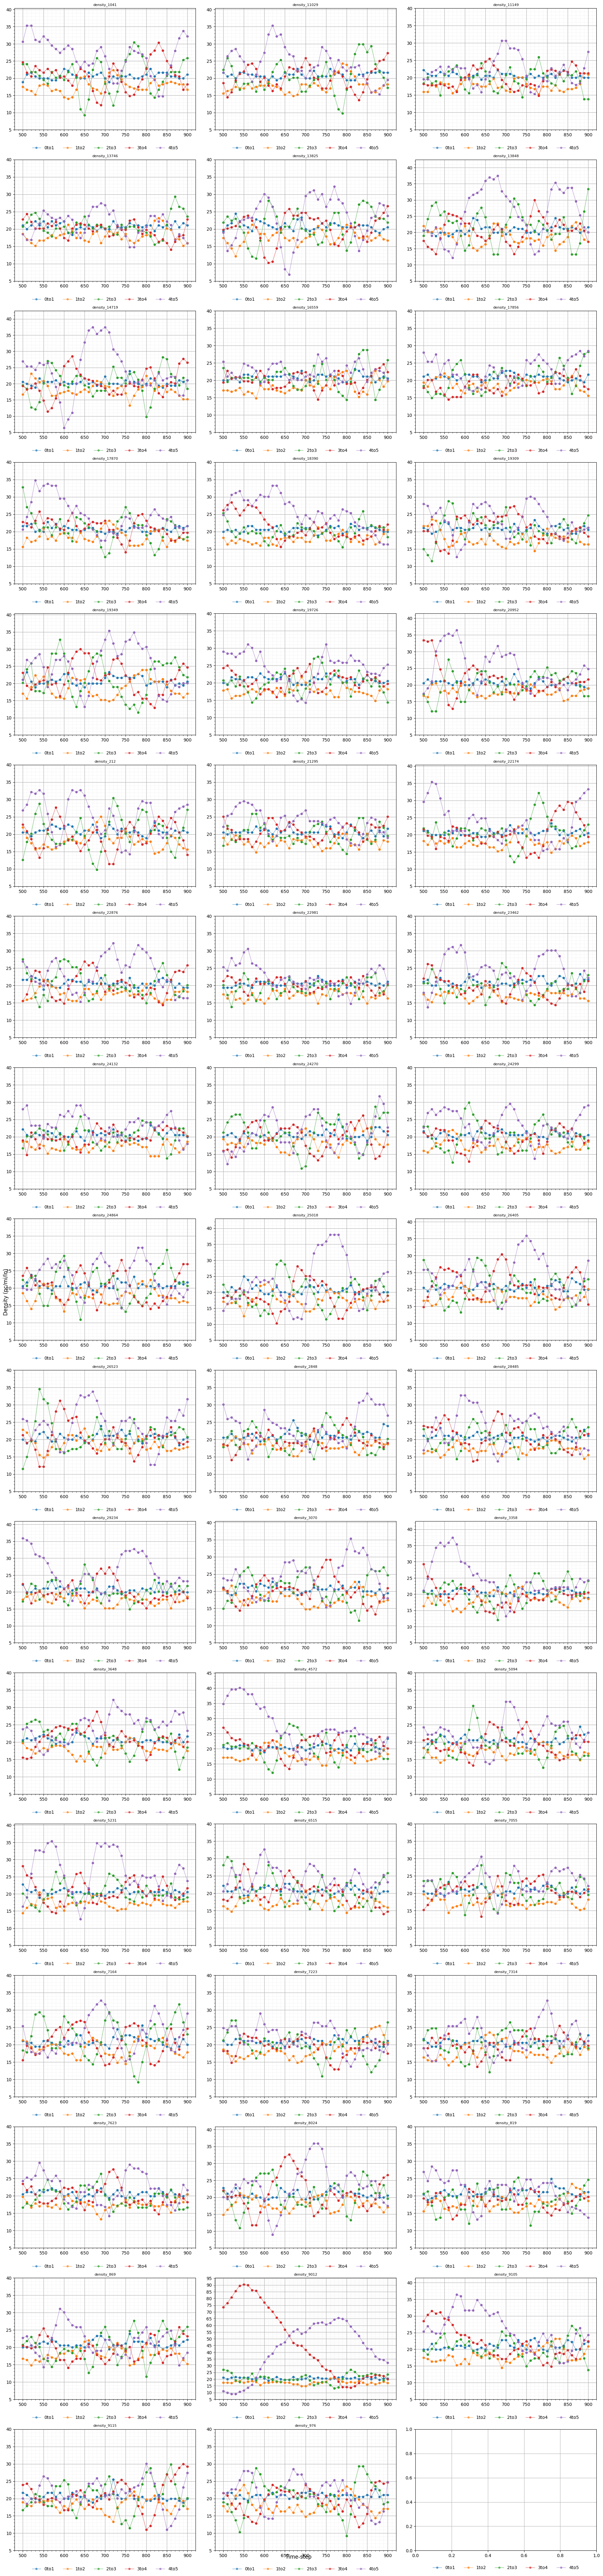

In [14]:
plot_all_density(tag=Tag.TEST, subplots_dim=(17,3), figsize=(19.5,82))